# OpenAI Agents SDK: Core Components & How It Works

This notebook walks through the OpenAI Agents SDK hands-on. Before the code, here is the map: the five core primitives the SDK is built from, and the loop that actually runs every time you call `Runner.run(...)`.

## The Building Blocks

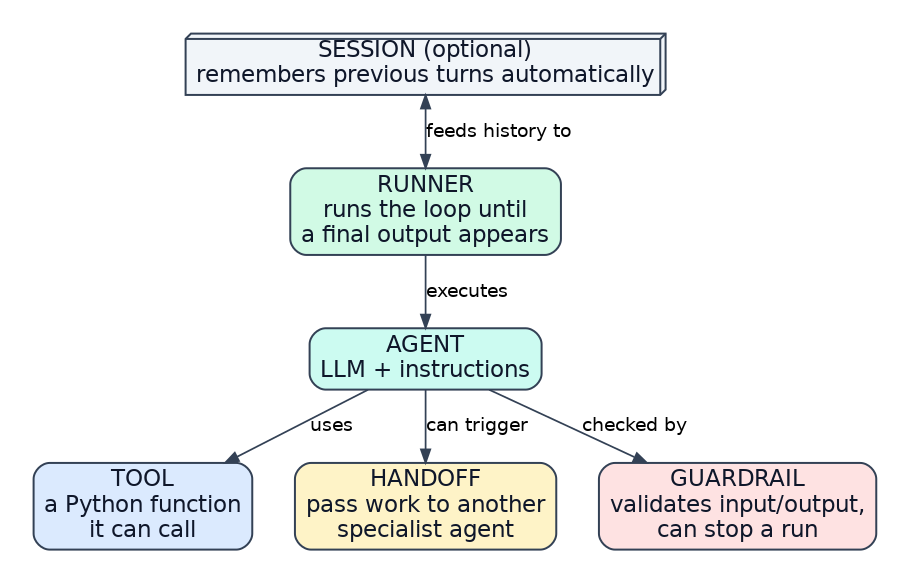

- **Agent**: an LLM given a name, instructions, and a set of tools it is allowed to use. This is the thing you *describe*.
- **Tool**: any Python function turned into something the agent can call. In this notebook, `@function_tool` does that conversion, generating the input schema automatically from the function's type hints and docstring.
- **Handoff**: a way for one agent to pass the conversation to a more specialized agent when a request falls outside its job. You'll see this in the *Multi-Agent Architecture* section below (`Planner Agent -> Calculation Agent -> Review Agent`).
- **Guardrail**: a check that runs alongside the agent to validate input or output and stop a run early if something looks wrong, before or after the expensive model call. Added as a new section further down.
- **Runner**: the engine that actually *executes* an agent: it is what runs the loop below. `Agent` describes, `Runner` executes; that split is the core idea behind everything in the SDK.
- **Session** *(optional)*: sits underneath all of this to remember previous turns automatically, so a follow-up question doesn't require resending the whole conversation by hand. Added as a new section further down.

## How a Run Actually Works, Step by Step

`Runner.run(...)` does not just call the model once. It runs a loop, and the loop only stops when the model is genuinely done:

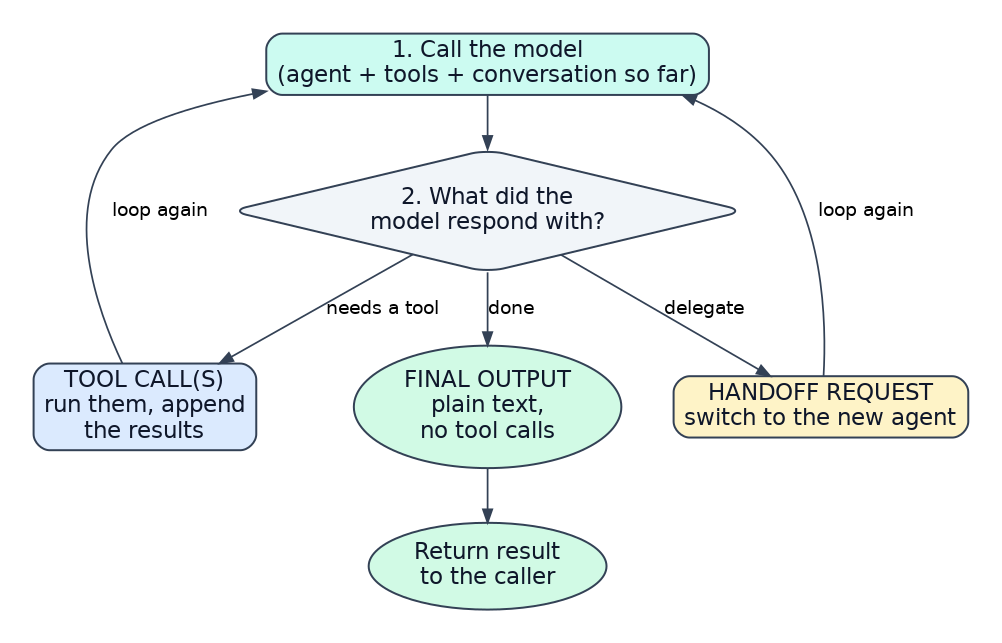

1. **Call the model**: the Runner sends the current agent's instructions, tools, and the conversation so far to the LLM.
2. **If it's final output** (plain text, no tool calls): the loop ends here and the result is returned to you.
3. **If it's a handoff request**: the model wants a different, more specialized agent to take over. The Runner switches the active agent and re-runs the loop with the new agent in charge.
4. **If it's one or more tool calls**: the model wants to run a function. The Runner executes it, appends the result to the conversation, and re-runs the loop so the model can see what the tool returned.
5. **Repeat** until the model produces a genuine final output, or a safety limit (`max_turns`) is reached.

> **Key idea:** "final output" specifically means text output with no tool calls attached. As long as the model keeps calling tools or requesting handoffs, the Runner keeps looping on your behalf, across every example below.

---

### What this notebook covers

1. A **manual** tool-calling agent built directly on the raw OpenAI client (no SDK), for comparison.
2. The same idea rebuilt properly with the **Agents SDK** (`Agent` + `Runner` + `@function_tool`).
3. A **single agent with multiple tools** (Financial Analyst Agent).
4. A **multi-agent handoff chain** (Planner -> Calculation Agent -> Review Agent).
5. **Guardrails**: validating input/output before the expensive agent runs.
6. **Sessions**: automatic multi-turn memory.
7. A separate technique (Corrective RAG with LangChain) included for comparison, not part of the Agents SDK itself.


## 1. Manual Tool-Calling (No SDK)

This first section is built directly on the raw `openai` client, with no Agents SDK involved. The model is asked to reply in a JSON envelope (`{"tool": "calculator", "input": ...}`) whenever it wants to use the calculator, and the surrounding Python code parses that JSON, runs the tool by hand, and sends the result back for a second model call.

This is exactly the manual version of the **Call model -> tool call -> append result -> call model again** loop shown above. Keep it in mind: the Agents SDK section right after this automates precisely this pattern.


In [1]:

# ============================================================
# 0. ENVIRONMENT SETUP — RUN THIS CELL FIRST
# ============================================================
# IMPORTANT:
# If you previously ran an older version of this notebook in
# the same Colab runtime, use:
# Runtime -> Restart session
# and then run this notebook from the top.
#
# The original notebook installed/imported `openai` first and
# installed `openai-agents` later. That can leave an old
# `openai` module in memory after pip upgrades and causes errors
# such as:
# ImportError: cannot import name 'ResponseShellCallCommandDoneEvent'
#
# We install ALL packages before importing them.

%pip install -q -U "openai>=2.25.0,<3" "openai-agents==0.19.2" "python-dotenv" "langchain" "langchain-openai" "langchain-community" "langchain-text-splitters" "faiss-cpu" "tiktoken"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 941.5/941.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.0/570.0 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

In [2]:

import os
from getpass import getpass

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

assert os.environ["OPENAI_API_KEY"], "OPENAI_API_KEY was not provided."
print("OPENAI_API_KEY is configured.")


Enter your OpenAI API key: ··········
OPENAI_API_KEY is configured.


In [3]:

# ============================================================
# VERIFY THE ENVIRONMENT BEFORE MAKING ANY API CALL
# ============================================================
import importlib.metadata as metadata
import openai
import agents

openai_version = metadata.version("openai")
agents_version = metadata.version("openai-agents")

print("Python:", __import__("sys").version.split()[0])
print("openai:", openai_version)
print("openai-agents:", agents_version)
print("OpenAI module:", openai.__file__)
print("Agents module:", agents.__file__)

# The Agents SDK currently requires Python >= 3.10.
assert tuple(map(int, __import__("sys").version.split(".")[:2])) >= (3, 10)
assert tuple(map(int, openai_version.split(".")[:2])) >= (2, 25)
assert agents_version == "0.19.2"

print("\nEnvironment check: PASS")


Python: 3.12.13
openai: 2.54.0
openai-agents: 0.19.2
OpenAI module: /usr/local/lib/python3.12/dist-packages/openai/__init__.py
Agents module: /usr/local/lib/python3.12/dist-packages/agents/__init__.py

Environment check: PASS


In [4]:
def calculator(expression: str) -> str:
    try:
        result = eval(expression)
        return str(result)
    except Exception as e:
        return f"Error: {str(e)}"

In [5]:

SYSTEM_PROMPT = """
You are a helpful AI assistant.

You can answer general questions and use the calculator tool when arithmetic is required.
"""


In [8]:
from openai import OpenAI

client = OpenAI()

In [6]:

import json

CALCULATOR_TOOL = {
    "type": "function",
    "function": {
        "name": "calculator",
        "description": "Evaluate a basic mathematical expression.",
        "parameters": {
            "type": "object",
            "properties": {
                "expression": {
                    "type": "string",
                    "description": "A mathematical expression such as 234 * 56"
                }
            },
            "required": ["expression"],
            "additionalProperties": False,
        },
    },
}

def run_agent(user_query: str) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_query},
    ]

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=messages,
        tools=[CALCULATOR_TOOL],
        tool_choice="auto",
    )

    message = response.choices[0].message

    if not message.tool_calls:
        return message.content or ""

    # Execute every requested tool call.
    messages.append(message.model_dump(exclude_none=True))

    for tool_call in message.tool_calls:
        if tool_call.function.name != "calculator":
            continue

        args = json.loads(tool_call.function.arguments)
        tool_result = calculator(args["expression"])

        messages.append({
            "role": "tool",
            "tool_call_id": tool_call.id,
            "content": tool_result,
        })

    final_response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=messages,
    )

    return final_response.choices[0].message.content or ""


In [9]:
print(run_agent("What is the capital of France?"))

The capital of France is Paris.


In [10]:
print(run_agent("What is 234 * 56?"))

234 multiplied by 56 is 13,104.


### AGENT Builder

With the manual version above as a baseline, this section rebuilds the same idea using the real **Agents SDK**. Three things change:

- `@function_tool` replaces hand-parsing JSON: it turns a plain Python function into a **Tool** the agent can call, with the schema generated automatically from the type hints and docstring.
- `Agent(...)` replaces the raw `system_prompt` string: instructions, tools, and model are now attached to a single object.
- `Runner.run(...)` replaces the manual two-call dance: it runs the full loop from the diagram above on its own, calling the tool and feeding the result back automatically.

**Note on the cell below:** the agent is asked *"What is weather in chennai"*, but no weather tool is attached, only `calculator`. Expect the agent to either answer from general knowledge or explain that it has no way to check live weather. This is a useful thing to point out live: an agent can only use tools it was actually given.


In [11]:

from agents import Agent, Runner, function_tool, WebSearchTool


In [12]:
@function_tool
def calculator(expression: str) -> str:
    """
    Evaluates a mathematical expression.
    Example input: "234 * 56"
    """
    try:
        result = eval(expression)
        return str(result)
    except Exception as e:
        return f"Error: {str(e)}"

In [13]:

agent = Agent(
    name="SimpleMathAgent",
    instructions="""
You are a helpful AI agent.

- Answer general knowledge questions directly.
- Use the calculator tool whenever mathematical computation is required.
- Always use the tool for arithmetic.
""",
    tools=[calculator],
    model="gpt-4o-mini",
)


In [14]:

# A plain agent does NOT automatically know live weather.
# WebSearchTool gives the agent access to current web information.
weather_agent = Agent(
    name="Weather Assistant",
    instructions="""
You provide current weather information.

Use web search for current weather questions.
For Chennai, India, report the latest available conditions and forecast.
Clearly state that weather information is live/current web data.
Keep the answer concise.
""",
    tools=[WebSearchTool(search_context_size="medium")],
    model="gpt-4o-mini",
)

result = await Runner.run(
    weather_agent,
    "What is the current weather in Chennai, India?"
)

print(result.final_output)


As of 2:02 PM IST on Thursday, August 20, 2026, the current weather in Chennai, India, is cloudy with a temperature of 94°F (35°C).

## Weather for Chennai, India:
Current Conditions: Cloudy, 94°F (35°C)

Daily Forecast:
* Thursday, August 20: Low: 80°F (26°C), High: 96°F (36°C), Description: Mostly cloudy and very warm; occasional rain this afternoon
* Friday, August 21: Low: 80°F (26°C), High: 97°F (36°C), Description: Overcast and very warm; a morning shower in spots followed by a thunderstorm in spots in the afternoon
* Saturday, August 22: Low: 79°F (26°C), High: 98°F (36°C), Description: Mostly cloudy and remaining very warm; a thunderstorm around in the afternoon
* Sunday, August 23: Low: 79°F (26°C), High: 96°F (36°C), Description: Partly sunny with a thunderstorm in spots in the afternoon
* Monday, August 24: Low: 79°F (26°C), High: 96°F (35°C), Description: High thin cloudiness in the morning, then rather cloudy in the afternoon with a brief shower or two
* Tuesday, August 25

### **Single Financial Analyst Agent**

A single **Agent** can hold more than one **Tool**. Here, one `financial_agent` is given two tools, `compound_interest` and `risk_score`, and the model itself decides which tool(s) to call and in what order, based on the instructions and the user's request. This is still a single pass through the same run loop: the model may emit two tool calls in one turn, the Runner executes both, appends both results, and lets the model produce the final explanation.


In [15]:

from agents import Agent, Runner, function_tool

@function_tool
def compound_interest(principal: float, rate: float, years: int) -> dict:
    """Calculate compound growth. Pass rate as a decimal, e.g. 0.08 for 8%."""
    amount = principal * ((1 + rate) ** years)
    return {
        "principal": principal,
        "rate": rate,
        "years": years,
        "final_amount": round(amount, 2),
    }

@function_tool
def risk_score(volatility: float, beta: float) -> dict:
    """Calculate a simple risk score as volatility multiplied by beta."""
    score = volatility * beta
    return {
        "volatility": volatility,
        "beta": beta,
        "risk_score": round(score, 3),
    }

financial_agent = Agent(
    name="Financial Analyst Agent",
    instructions="""
You are a financial analyst.
Use tools whenever calculations are required.
Explain the results clearly and show the important numbers.
""",
    tools=[compound_interest, risk_score],
    model="gpt-4o-mini",
)

result = await Runner.run(
    financial_agent,
    """
If I invest 10000 at 8% for 5 years,
and volatility is 0.2 and beta is 1.3,
calculate final amount and risk score.
""",
)

print(result.final_output)


### Investment Results

1. **Final Amount After 5 Years**:
   - **Initial Investment**: $10,000
   - **Annual Interest Rate**: 8%
   - **Investment Duration**: 5 years
   
   The final amount after 5 years is **$14,693.28**.

2. **Risk Assessment**:
   - **Volatility**: 0.2
   - **Beta**: 1.3

   The calculated risk score is **0.26**.

### Summary:
- Investing $10,000 at an 8% interest rate for 5 years will yield approximately **$14,693.28**.
- The risk score, indicating the investment's volatility relative to the market, is **0.26**. This score suggests moderate risk based on the provided volatility and beta values.


### **Multi-Agent Architecture**

So far every example has used one agent. This section introduces **Handoffs**: a `planner_agent` is given no tools of its own, only a list of other agents to delegate to (`handoffs=[calculation_agent, review_agent]`). The instructions tell it *how* to break the work up and *in what order* to hand off.

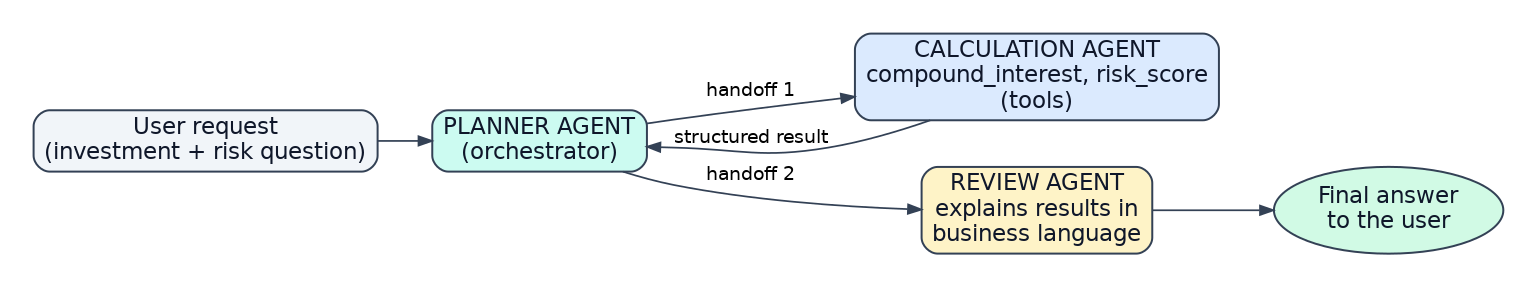

Notice how this maps to the run loop: when the Planner Agent's response is a handoff request rather than a final answer, the Runner does not stop, it swaps in the new active agent (Calculation Agent, then Review Agent) and keeps looping, exactly as shown in the loop diagram at the top of this notebook.


In [16]:

from agents import Agent, Runner, function_tool

@function_tool
def compound_interest(principal: float, rate: float, years: int) -> dict:
    """Calculate compound growth. Rate must be a decimal."""
    amount = principal * ((1 + rate) ** years)
    return {"final_amount": round(amount, 2)}

@function_tool
def risk_score(volatility: float, beta: float) -> dict:
    """Calculate volatility multiplied by beta."""
    return {"risk_score": round(volatility * beta, 3)}

calculation_agent = Agent(
    name="Calculation Agent",
    instructions="""
Perform financial calculations.
Always use the available calculation tools.
Return the calculated values clearly.
""",
    tools=[compound_interest, risk_score],
    model="gpt-4o-mini",
)

review_agent = Agent(
    name="Review Agent",
    instructions="""
Review the supplied financial calculation results.
Explain them clearly in business language.
Add concise interpretation and risk commentary.
Do not invent numbers.
""",
    model="gpt-4o-mini",
)

planner_agent = Agent(
    name="Planner Agent",
    instructions="""
You are the manager/orchestrator.

1. Send the user's financial calculation request to the Calculation Agent.
2. Give the calculation result to the Review Agent.
3. Return the Review Agent's explanation as the final answer.

Do not perform the financial calculations yourself when a specialist can do them.
""",
    tools=[
        calculation_agent.as_tool(
            tool_name="calculate_financials",
            tool_description="Perform the requested financial calculations using the calculation tools.",
        ),
        review_agent.as_tool(
            tool_name="review_financial_result",
            tool_description="Review and explain a financial calculation result in business language.",
        ),
    ],
    model="gpt-4o-mini",
)


In [17]:

result = await Runner.run(
    planner_agent,
    """
    Calculate the final amount for 10000 invested at 8% for 5 years,
    and calculate risk score for volatility 0.2 and beta 1.3.
    Then review and explain the result.
    """
)

print(result.final_output)


### Investment Calculation Summary

1. **Final Investment Amount**:  
   - **Initial Investment**: $10,000  
   - **Interest Rate**: 8%  
   - **Duration**: 5 years  
   - **Result**: The total amount after 5 years is **$14,693.28**.

   **Interpretation**:
   - The investment has increased by **$4,693.28** due to the effects of compound interest, which shows the power of reinvesting earnings.

2. **Risk Score Calculation**:  
   - **Volatility**: 0.2  
   - **Beta**: 1.3  
   - **Risk Score**: **0.26**

   **Explanation**:
   - **Moderate Risk**: The risk score suggests a moderate level of risk. A beta of 1.3 indicates that this asset tends to be more volatile than the market, potentially increasing both opportunities for higher returns and risks during downturns.

### Risk Commentary

- **Investment Growth**: The investment demonstrates strong growth potential, appealing for long-term strategies.

- **Market Conditions**: Be mindful that while this investment can yield robust returns

## Guardrails

None of the agents above validate their input or output before running. A **Guardrail** is a check that runs alongside an agent: an input guardrail runs on the very first user message, before (or in parallel with) the main agent, and can stop the run immediately via a **tripwire** if something looks wrong, for example a request that is clearly off-topic or abusive for an expensive model to handle.

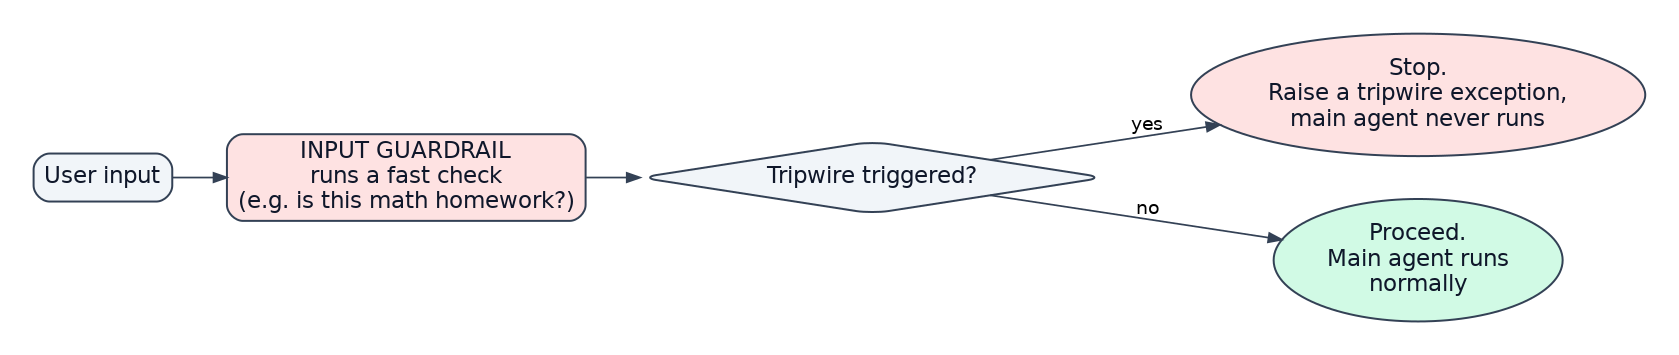

The official pattern uses a small, cheap "guardrail agent" with a structured output type to make the check itself. The example below follows the official docs directly: a customer support agent should refuse to do someone's math homework, so a guardrail agent checks the input first and raises `InputGuardrailTripwireTriggered` if it detects a math-homework request.


In [18]:

from pydantic import BaseModel
from agents import (
    Agent,
    GuardrailFunctionOutput,
    InputGuardrailTripwireTriggered,
    RunContextWrapper,
    Runner,
    TResponseInputItem,
)
from agents.decorators import input_guardrail

class MathHomeworkOutput(BaseModel):
    is_math_homework: bool
    reasoning: str

guardrail_agent = Agent(
    name="Guardrail check",
    instructions="""
Determine whether the user is asking the assistant to solve math homework.
Return true only when it is clearly homework that the user wants solved.
""",
    output_type=MathHomeworkOutput,
    model="gpt-4o-mini",
)

@input_guardrail
async def math_guardrail(
    ctx: RunContextWrapper[None],
    agent: Agent,
    input: str | list[TResponseInputItem],
) -> GuardrailFunctionOutput:
    result = await Runner.run(
        guardrail_agent,
        input,
        context=ctx.context,
    )

    return GuardrailFunctionOutput(
        output_info=result.final_output,
        tripwire_triggered=result.final_output.is_math_homework,
    )

support_agent = Agent(
    name="Customer support agent",
    instructions="You are a customer support agent. Help customers with their questions.",
    input_guardrails=[math_guardrail],
    model="gpt-4o-mini",
)

try:
    result = await Runner.run(
        support_agent,
        "Hello, can you help me solve for x: 2x + 3 = 11?"
    )
    print(result.final_output)
except InputGuardrailTripwireTriggered:
    print("Math homework guardrail tripped: the support agent refused to run.")


Math homework guardrail tripped: the support agent refused to run.


## Sessions

Every `Runner.run(...)` call above starts a fresh conversation with no memory of previous calls. A **Session** fixes that: it is optional automatic memory that sits between your calls and the Runner, so a follow-up question can refer back to something said earlier without you manually resending the whole conversation.

`SQLiteSession` is the simplest built-in option: pass it a conversation ID (and, optionally, a database file for persistence across restarts), then pass the same `session=` object to every `Runner.run(...)` call that belongs to that conversation.


In [21]:
# ============================================================
# GLOBAL AGENTS SDK CONFIGURATION
# ============================================================

import os

os.environ["OPENAI_DEFAULT_MODEL"] = "gpt-4o-mini"

print("Default Agents SDK model:",
      os.environ["OPENAI_DEFAULT_MODEL"])

Default Agents SDK model: gpt-4o-mini


In [22]:
from agents import Agent, Runner, SQLiteSession

assistant = Agent(
    name="Assistant",
    instructions="Reply very concisely.",
)

# In-memory session (use SQLiteSession("user-42", "conversations.db") for a persistent file instead)
session = SQLiteSession("conversation_123")

# First turn
result = await Runner.run(assistant, "What city is the Golden Gate Bridge in?", session=session)
print(result.final_output)  # "San Francisco"

# Second turn: the agent automatically remembers the previous turn via the session
result = await Runner.run(assistant, "What state is it in?", session=session)
print(result.final_output)  # "California"


San Francisco.
California.


---

**Note:** the section below (Corrective RAG) is a separate retrieval technique built with LangChain, not the OpenAI Agents SDK. It is included here for comparison, since both patterns solve a similar underlying problem (getting a reliable, grounded answer out of an LLM) in different ways: the Agents SDK sections above use tools, handoffs and guardrails; CRAG below uses a retrieve -> evaluate -> rewrite -> re-retrieve -> answer pipeline over a vector store.


### **CRAG**

In [ ]:

# All dependencies were installed in the environment setup cell at the top.
# Do not reinstall OpenAI/OpenAI Agents after importing them.


In [23]:
import os
from getpass import getpass

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

/tmp/ipykernel_1555/3196058774.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [24]:

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
)


In [25]:
documents = [
    Document(page_content="""
    Standard RAG retrieves documents and generates answers from them.
    It may still hallucinate if retrieval is weak.
    """),

    Document(page_content="""
    Corrective RAG evaluates retrieval quality.
    If documents are insufficient, it rewrites the query and re-retrieves.
    """),

    Document(page_content="""
    Retrieval evaluation improves factual reliability in enterprise systems.
    """)
]

In [26]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)

docs = splitter.split_documents(documents)

vectorstore = FAISS.from_documents(docs, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

In [27]:
evaluation_prompt = ChatPromptTemplate.from_template("""
You are a retrieval evaluator.

Question:
{question}

Retrieved Context:
{context}

Is the context sufficient to answer the question?

Respond ONLY with:
SUFFICIENT
or
INSUFFICIENT
""")

In [28]:
rewrite_prompt = ChatPromptTemplate.from_template("""
Rewrite this question to improve document retrieval precision.

Original Question:
{question}
""")

In [29]:
answer_prompt = ChatPromptTemplate.from_template("""
Answer strictly using the context below.

Question:
{question}

Context:
{context}

If insufficient information exists, say:
"I do not have enough information."
""")

In [30]:
evaluation_chain = evaluation_prompt | llm
rewrite_chain = rewrite_prompt | llm
answer_chain = answer_prompt | llm

In [31]:
class CRAGState:
    def __init__(self, question):
        self.original_question = question
        self.current_question = question
        self.context = ""
        self.retrieval_evaluation = None
        self.rewritten = False

In [32]:
def retrieve_step(state: CRAGState):
    docs = retriever.invoke(state.current_question)
    state.context = "\n\n".join([d.page_content for d in docs])
    return state

In [33]:
def evaluate_step(state: CRAGState):
    result = evaluation_chain.invoke({
        "question": state.current_question,
        "context": state.context
    })

    state.retrieval_evaluation = result.content.strip()
    return state

In [34]:
def rewrite_step(state: CRAGState):

    if "INSUFFICIENT" in state.retrieval_evaluation:

        result = rewrite_chain.invoke({
            "question": state.original_question
        })

        state.current_question = result.content.strip()
        state.rewritten = True

        # Re-retrieve
        retrieve_step(state)

    return state

In [35]:
def generate_answer_step(state: CRAGState):

    result = answer_chain.invoke({
        "question": state.original_question,
        "context": state.context
    })

    return result.content

In [36]:
def corrective_rag_pipeline(question: str):

    state = CRAGState(question)

    # Initial retrieval
    retrieve_step(state)

    # Evaluate retrieval
    evaluate_step(state)

    print("Retrieval Evaluation:", state.retrieval_evaluation)

    # Correct if needed
    rewrite_step(state)

    if state.rewritten:
        print("Query was rewritten to:", state.current_question)

    # Final answer
    answer = generate_answer_step(state)

    return answer

In [37]:
response = corrective_rag_pipeline(
    "How does corrective RAG improve reliability?"
)

print("\nFinal Answer:\n", response)

Retrieval Evaluation: SUFFICIENT

Final Answer:
 Corrective RAG improves reliability by evaluating retrieval quality and rewriting the query to re-retrieve documents if the initial documents are insufficient. This process enhances factual reliability in enterprise systems by ensuring that the information retrieved is more accurate and relevant.


## Final End-to-End Smoke Test

Run this last. It confirms that the installed OpenAI and Agents SDK packages can import together and that a real Agents SDK request succeeds.


In [ ]:

import importlib.metadata as metadata
from agents import Agent, Runner

print("openai:", metadata.version("openai"))
print("openai-agents:", metadata.version("openai-agents"))

smoke_agent = Agent(
    name="Smoke Test Agent",
    instructions="Answer in one short sentence.",
    model="gpt-4o-mini",
)

smoke_result = await Runner.run(
    smoke_agent,
    "What is 2 + 2?"
)

print("Agent response:", smoke_result.final_output)
print("\nFINAL SMOKE TEST: PASS")
